# 👔 IBM HR Analytics — Employee Attrition Prediction

**By:** Chanchal | NIT JSR | Production & Industrial Engineering

## Objective
Predict which employees are likely to leave the company using ML.
This is a real consulting-style analysis used by HR teams at Fortune 500 companies.

## Questions Explored
1. Who is most likely to leave?
2. What factors drive attrition?
3. Which ML model best predicts attrition on imbalanced data?
4. What should the company do to reduce attrition?

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Overview & Cleaning
Dropping useless columns — EmployeeNumber (ID), Over18 (all Y),
StandardHours (all 80), EmployeeCount (all 1), and low impact features.
Also dropping HourlyRate, DailyRate, MonthlyRate — mean/median analysis
showed these add little value over MonthlyIncome.

In [110]:
# Drop useless columns
df = df.drop(columns=['Over18', 'EmployeeCount', 'StandardHours',
                       'EmployeeNumber', 'RelationshipSatisfaction',
                       'BusinessTravel', 'HourlyRate', 'DailyRate', 'MonthlyRate'])

print(f"Shape after dropping: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum().sum()} total missing values")
print(f"\nTarget Distribution:\n{df['Attrition'].value_counts()}")

Shape after dropping: (1470, 26)

Missing Values:
0 total missing values

Target Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


## Exploratory Data Analysis
Exploring which factors are associated with employee attrition.

/tmp/ipykernel_802/2403074162.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='RdPu', ax=axes[0,2])


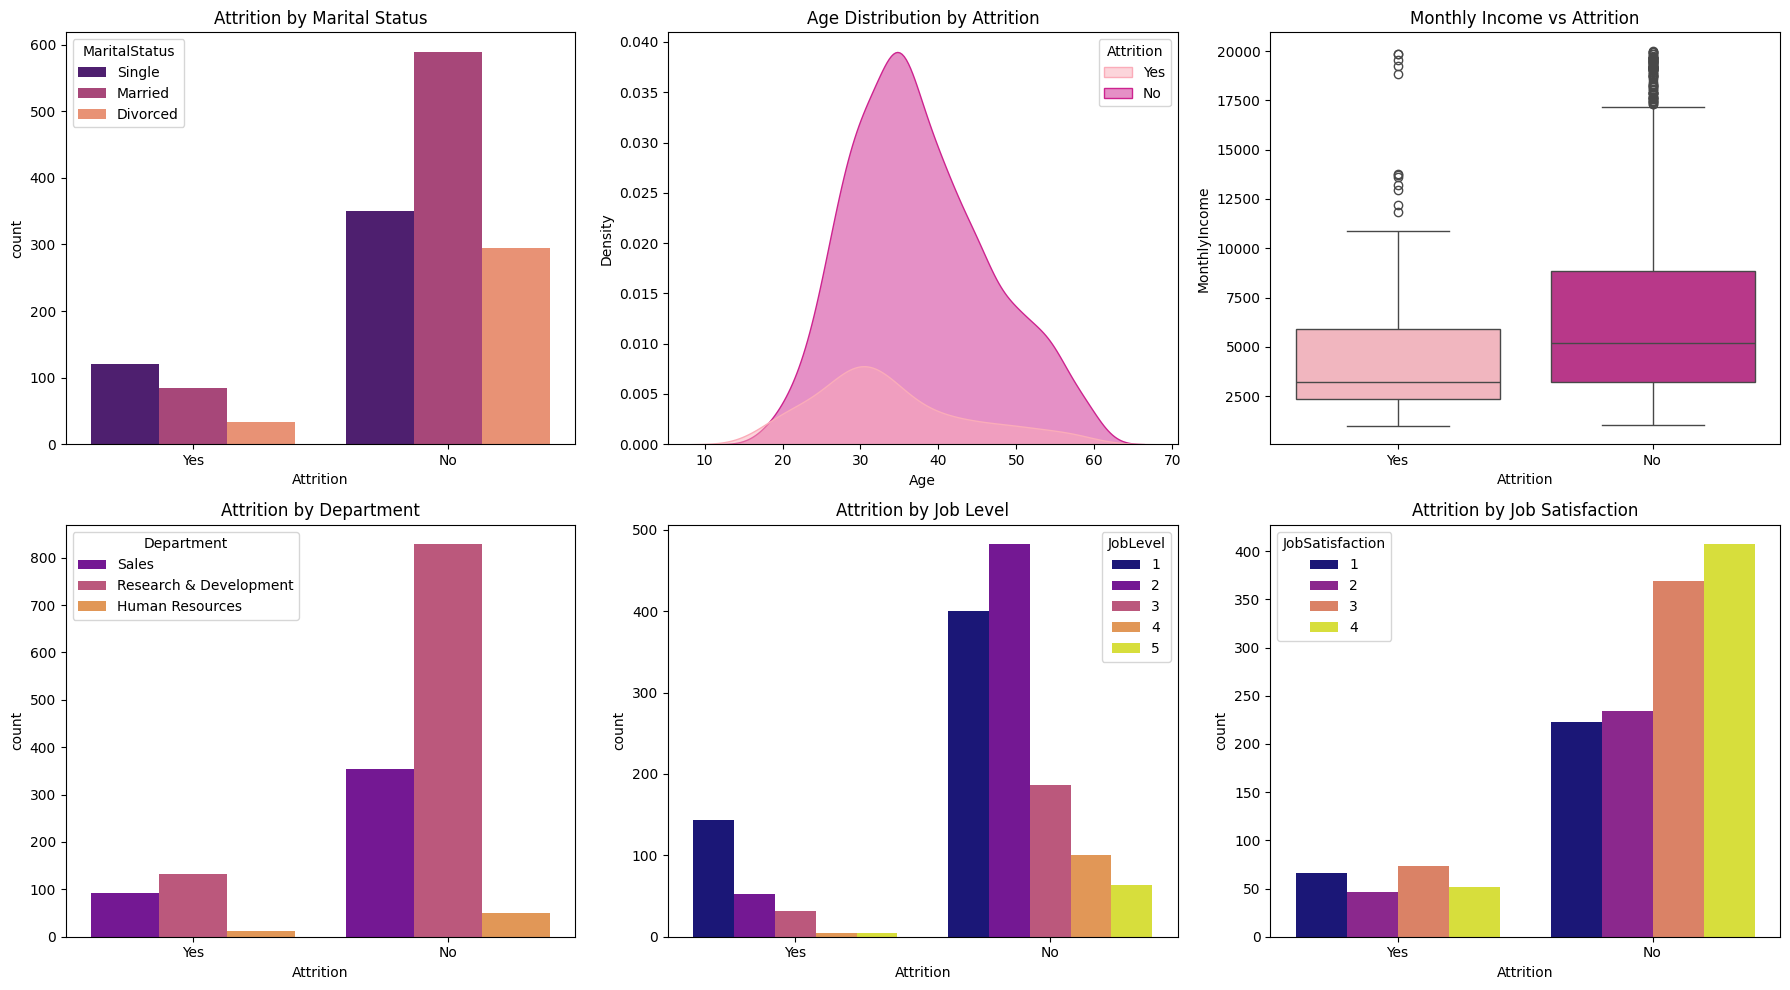

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Marital Status
sns.countplot(x='Attrition', hue='MaritalStatus', data=df, palette='magma', ax=axes[0,0])
axes[0,0].set_title("Attrition by Marital Status")

# 2. Age Distribution
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, palette='RdPu', alpha=0.5, ax=axes[0,1])
axes[0,1].set_title("Age Distribution by Attrition")

# 3. Monthly Income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='RdPu', ax=axes[0,2])
axes[0,2].set_title("Monthly Income vs Attrition")

# 4. Department
sns.countplot(x='Attrition', hue='Department', data=df, palette='plasma', ax=axes[1,0])
axes[1,0].set_title("Attrition by Department")

# 5. Job Level
sns.countplot(x='Attrition', hue='JobLevel', data=df, palette='plasma', ax=axes[1,1])
axes[1,1].set_title("Attrition by Job Level")

# 6. Job Satisfaction
sns.countplot(x='Attrition', hue='JobSatisfaction', data=df, palette='plasma', ax=axes[1,2])
axes[1,2].set_title("Attrition by Job Satisfaction")

plt.tight_layout()
plt.show()

### EDA Findings
- **Singles** leave more than married/divorced employees
- **Early 30s** employees have highest attrition — exploring career options
- **Lower income** employees leave significantly more
- **R&D department** has most attrition in absolute numbers
- **Job Level 1** (entry level) leaves most — lack of growth
- **Low job satisfaction (1)** strongly associated with leaving

## Feature Engineering & Encoding
Converting categorical columns to numeric for ML models.

In [113]:
# Label encoding
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# One hot encoding
df = pd.get_dummies(df, columns=['Department'], drop_first=True)
df = pd.get_dummies(df, columns=['MaritalStatus'], drop_first=True)
df = pd.get_dummies(df, columns=['JobRole'], drop_first=True)
df = pd.get_dummies(df, columns=['EducationField'], drop_first=True)

print(f"Final shape: {df.shape}")
print(f"Any object columns left: {df.dtypes[df.dtypes == 'object'].shape[0]}")

Final shape: (1470, 39)
Any object columns left: 0


## Train Test Split & Scaling
80% training, 20% testing. MinMaxScaler for models that need scaling.

In [114]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training size: {X_train.shape}")
print(f"Testing size: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training size: (1176, 38)
Testing size: (294, 38)

Class distribution in training set:
Attrition
0    978
1    198
Name: count, dtype: int64


## Model Comparison
Testing 4 models. Note: Dataset is imbalanced (84% No, 16% Yes).
Accuracy alone is misleading — focus on AUC and Recall for class 1!
A lazy model predicting "No" for everyone gets 84% accuracy but is useless.

In [115]:
models = {
    'Logistic Regression': (LogisticRegression(), X_train_scaled, X_test_scaled),
    'Decision Tree': (DecisionTreeClassifier(max_depth=3, random_state=42), X_train, X_test),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test),
    'KNN': (KNeighborsClassifier(n_neighbors=7), X_train_scaled, X_test_scaled),
}

print("Model Comparison:")
print("-" * 55)
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name}: Accuracy={acc*100:.2f}%, AUC={auc:.3f}")

Model Comparison:
-------------------------------------------------------
Logistic Regression: Accuracy=87.76%, AUC=0.760
Decision Tree: Accuracy=85.37%, AUC=0.611
Random Forest: Accuracy=87.07%, AUC=0.717
KNN: Accuracy=88.78%, AUC=0.594


## Handling Class Imbalance
Standard models predict "No" for almost everyone → high accuracy but useless!
Using class_weight='balanced' to make model focus on minority class (leavers).

In [116]:
# Balanced Logistic Regression
lr_balanced = LogisticRegression(class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = lr_balanced.predict(X_test_scaled)

print("Balanced Logistic Regression:")
print(classification_report(y_test, y_pred_balanced))

Balanced Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      0.75      0.84       255
           1       0.30      0.69      0.42        39

    accuracy                           0.74       294
   macro avg       0.62      0.72      0.63       294
weighted avg       0.86      0.74      0.78       294



## Feature Importance — What Drives Attrition?
Using Random Forest to identify which factors matter most.

/tmp/ipykernel_802/1897851381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='plasma')


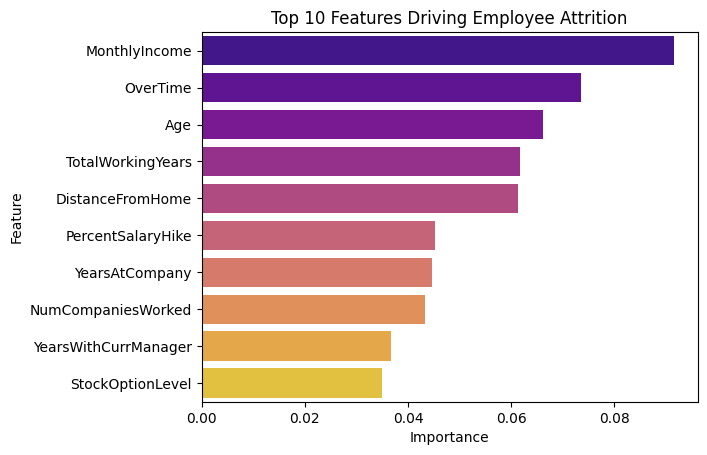

In [118]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='plasma')
plt.title("Top 10 Features Driving Employee Attrition")
plt.show()

## 🔍 Key Conclusions

1. **Who leaves:** Young entry-level employees (early 30s, Job Level 1)
   with low income working overtime and living far from office

2. **Why they leave:** Low pay despite overtime, poor work-life balance,
   lack of growth opportunities at junior levels

3. **Best model:** Balanced Logistic Regression — Recall for leavers jumped
   from 31% to 69%. For imbalanced data, Recall matters more than accuracy!

4. **Business recommendations:**
   - Offer work from home for employees living 30+ km away
   - Provide overtime bonuses and salary benchmarking
   - Create clear growth paths for Job Level 1 employees
   - Focus retention efforts on R&D and Sales departments

5. **Key ML lesson:** Accuracy is misleading on imbalanced data.
   A model predicting "No" for everyone gets 84% accuracy but catches
   zero people who actually leave — completely useless for business!

## 💡 Final Conclusion
> Employee attrition is predictable and preventable. Data shows that
> compensation, work-life balance, and career growth are the three
> pillars of employee retention. Fix these → reduce attrition significantly.